# Offline Training of a NN for the parameterization problem of L96

In [25]:
%matplotlib inline
import sys
import os
import time
from IPython.display import Image

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.utils.data as Data
from torch import nn, optim

current_dir = os.path.abspath(os.getcwd())
parent_dir = os.path.dirname(current_dir)
sys.path.append(parent_dir)

from src.l96_model import L96, RK2, RK4, EulerFwd, L96_eq1_xdot, integrate_L96_2t

In [26]:
np.random.seed(14)
torch.manual_seed(14);
# set device to GPU if available
print("PyTorch version:", torch.__version__)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

PyTorch version: 2.5.1
Using device: cuda


## Building the *real world* to generate the *ground truth* dataset

We run a two time-scale L96 model to generate the *ground truth* dataset. We set $K = 8$, $J = 32$, and run the model for 20000 time steps.

In [27]:
time_steps = 20000
dt = 0.01
T = time_steps * dt
forcing = 18

W = L96(K=8, J=32, F=forcing)

In [28]:
X_true, _, _, xy_true = W.run(dt, T, store=True, return_coupling=True)
X_true, xy_true = X_true.astype(np.float32), xy_true.astype(np.float32)

#### Data Splitting

In [29]:
test_size = int(0.2 * time_steps)

X_true_train = X_true[:-test_size, :]
subgrid_tendencies_train = xy_true[:-test_size, :]

X_true_test = X_true[-test_size:, :]
subgrid_tendencies_test = xy_true[-test_size:, :]

len(X_true_train), len(X_true_test), len(subgrid_tendencies_train), len(subgrid_tendencies_test), X_true_train.shape, subgrid_tendencies_train.shape, X_true_test.shape, subgrid_tendencies_test.shape

(16001, 4000, 16001, 4000, (16001, 8), (16001, 8), (4000, 8), (4000, 8))

### Dataloaders

This allows for batching. To be more precise, iterating over a dataset.

In [30]:
BATCH_SIZE = 2000

In [ ]:
local_dataset = Data.TensorDataset(torch.from_numpy(np.reshape(X_true_train, -1)), torch.from_numpy(np.reshape(subgrid_tendencies_train, -1))) # Data here means torch.utils.data which is a PyTorch utility for data loading and preprocessing. The TensorDataset class is used to create a dataset from tensors, which can then be used with a DataLoader for batching and shuffling. This means we just created a Tensor dataset from the training data, which will be used to train the neural network. The TensorDataset takes in two tensors: the input data (X_true_train) and the target data (subgrid_tendencies_train). The tensors are reshaped to be one-dimensional using np.reshape() before being passed to the TensorDataset constructor. This is done because the DataLoader expects the input and target tensors to have the same shape, and reshaping them to be one-dimensional ensures that they have the same number of elements.
local_dataloader = Data.DataLoader(dataset=local_dataset, batch_size=BATCH_SIZE, shuffle=True) # The DataLoader class is used to create an iterable over the dataset, which can be used to load batches of data during training. The batch_size parameter specifies the number of samples to load in each batch, and the shuffle parameter specifies whether to shuffle the data before loading it. In this case, we set shuffle=True to ensure that the data is randomly shuffled before each epoch of training. This helps to prevent overfitting and improve generalization performance.

In [32]:
local_dataset_test = Data.TensorDataset(torch.from_numpy(np.reshape(X_true_test, -1)), torch.from_numpy(np.reshape(subgrid_tendencies_test, -1)))
local_dataloader_test = Data.DataLoader(dataset=local_dataset_test, batch_size=BATCH_SIZE, shuffle=True)

X (state): 
tensor([12.9715,  5.3797,  0.8659,  ...,  8.3222, -2.6947,  4.2560])

Subgrid Tendencies: 
tensor([-7.5589, -6.6147, -0.8452,  ..., -7.2965,  4.5814, -7.6241])



(-12.0, 16.0)

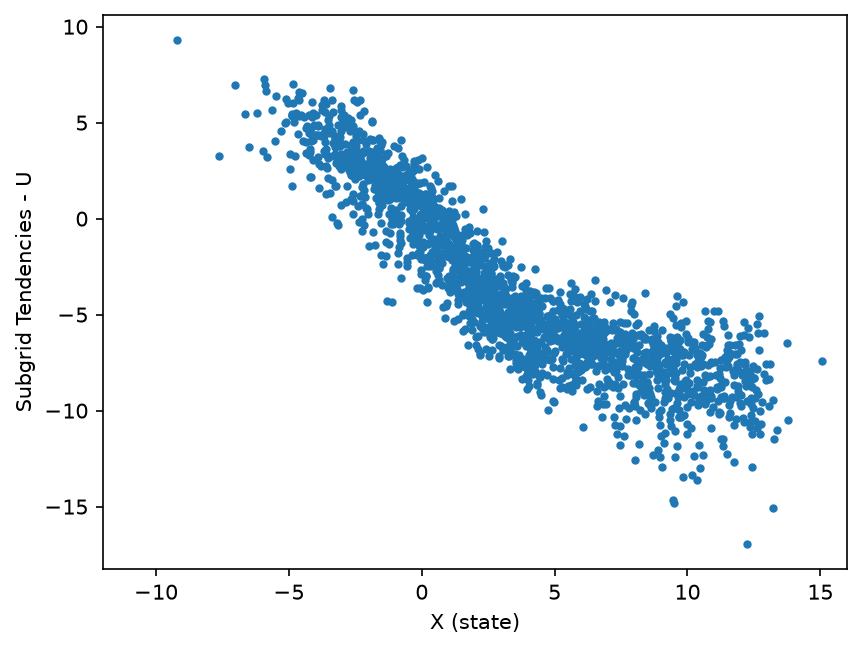

In [33]:
data_iterator = iter(local_dataloader)
X_iter, subgrid_tendencies_iter = next(data_iterator)

print(f"X (state): \n{X_iter}\n")
print(f"Subgrid Tendencies: \n{subgrid_tendencies_iter}\n")

plt.figure(dpi=150)
plt.plot(X_iter, subgrid_tendencies_iter, '.')
plt.xlabel('X (state)')
plt.ylabel('Subgrid Tendencies - U')
plt.xlim([-12, 16])

In [34]:
class LinearRegression(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(1, 1) # single input and single output
    def forward(self, x):
        return self.linear1(x)
        return x

In [35]:
linear_network = LinearRegression()
linear_network

LinearRegression(
  (linear1): Linear(in_features=1, out_features=1, bias=True)
)

In [36]:
class FCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(1, 16) # single input and 16 outputs
        self.linear2 = nn.Linear(16, 16) # 16 inputs and 16 outputs
        self.linear3 = nn.Linear(16, 1) # 16 inputs and single output
        self.relu = nn.ReLU() # ReLU activation function

    def forward(self, x):
        x = self.relu(self.linear1(x)) # apply linear1 and ReLU
        x = self.relu(self.linear2(x)) # apply linear2 and ReLU
        x = self.linear3(x) # apply linear3
        return x

In [37]:
fcnn_network = FCNN()
fcnn_network

FCNN(
  (linear1): Linear(in_features=1, out_features=16, bias=True)
  (linear2): Linear(in_features=16, out_features=16, bias=True)
  (linear3): Linear(in_features=16, out_features=1, bias=True)
  (relu): ReLU()
)

The number of layers and width of layers are hyperparameters, which the practitioner needs to set based on some trial and error (or systematic hyperparameter sweeps).

In [38]:
loss_fn = nn.MSELoss() # Mean Squared Error Loss

In [39]:
def train_model(network, criterion, loader, optimizer, device):
    network.train() # set the network to training mode
    train_loss = 0 # initialize the training loss to zero
    for batch_x, batch_y in loader:
        batch_x = batch_x.to(device, non_blocking=True)
        batch_y = batch_y.to(device, non_blocking=True)
        if len(batch_x.shape) == 1:
            prediction = torch.squeeze(network(torch.unsqueeze(batch_x, 1))) # if the input is 1D, unsqueeze it to make it 2D
        else:
            prediction = network(batch_x) # if the input is 2D, pass it directly to the network
        loss = criterion(prediction, batch_y) # compute the loss
        train_loss += loss.item()

        optimizer.zero_grad() # zero the gradients
        loss.backward() # backpropagate the loss
        optimizer.step() # update the weights
    return train_loss / len(loader) # return the average training loss

In [40]:
def test_model(network, criterion, loader, device):
    network.eval() # set the network to evaluation mode
    test_loss = 0 # initialize the test loss to zero
    with torch.no_grad(): # disable gradient computation
        for batch_x, batch_y in loader:
            batch_x = batch_x.to(device, non_blocking=True)
            batch_y = batch_y.to(device, non_blocking=True)
            if len(batch_x.shape) == 1:
                prediction = torch.squeeze(network(torch.unsqueeze(batch_x, 1))) # if the input is 1D, unsqueeze it to make it 2D
            else:
                prediction = network(batch_x) # if the input is 2D, pass it directly to the network
            loss = criterion(prediction, batch_y) # compute the loss
            test_loss += loss.item()
    return test_loss / len(loader) # return the average test loss

In [41]:
def fit_model(network, criterion, optimizer, train_loader, test_loader, n_epochs, device):
    network = network.to(device) # move the network to the specified device (CPU or GPU)
    train_losses, test_losses = [], [] # initialize lists to store training and test losses
    start_time = time.time() # record the start time
    for epoch in range(1, n_epochs + 1):
        train_loss = train_model(network, criterion, train_loader, optimizer, device) # train the model and get the training loss
        test_loss = test_model(network, criterion, test_loader, device) # test the model and get the test loss
        train_losses.append(train_loss) # append the training loss to the list
        test_losses.append(test_loss) # append the test loss to the list
        if epoch % 10 == 0 or epoch == 1: # print the losses every 10 epochs and at the first epoch
            print(f'Epoch {epoch}/{n_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}')
    end_time = time.time() # record the end time
    print(f'Training completed in {end_time - start_time:.2f} seconds.')
    return train_losses, test_losses # return the training and test losses

In [42]:
n_epochs = 15

In [43]:
learning_rate = 0.003
momentum = 0.1
optimizer_linear = optim.Adam(linear_network.parameters(), lr=learning_rate)
optimizer_fcnn = optim.Adam(fcnn_network.parameters(), lr=learning_rate)

In [45]:
train_loss_linear, test_loss_linear = fit_model(linear_network, loss_fn, optimizer_linear, local_dataloader, local_dataloader_test, n_epochs, device)

Epoch 1/15, Train Loss: 86.6424, Test Loss: 75.4724
Epoch 10/15, Train Loss: 6.6432, Test Loss: 5.9877
Training completed in 41.40 seconds.


In [46]:
train_loss_fcnn, test_loss_fcnn = fit_model(fcnn_network, loss_fn, optimizer_fcnn, local_dataloader, local_dataloader_test, n_epochs, device)

Epoch 1/15, Train Loss: 10.2790, Test Loss: 3.7124
Epoch 10/15, Train Loss: 2.8399, Test Loss: 2.6684
Training completed in 45.63 seconds.


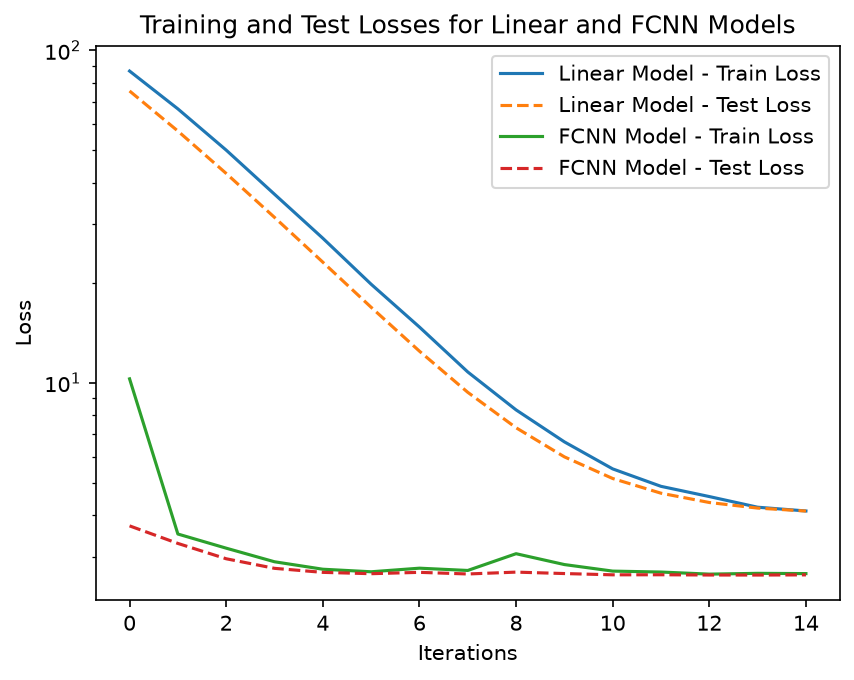

In [47]:
plt.figure(dpi=150)
plt.plot(train_loss_linear, label='Linear Model - Train Loss')
plt.plot(test_loss_linear, linestyle='--', label='Linear Model - Test Loss')

plt.plot(train_loss_fcnn, label='FCNN Model - Train Loss')
plt.plot(test_loss_fcnn, linestyle='--', label='FCNN Model - Test Loss')

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Training and Test Losses for Linear and FCNN Models')
plt.show();

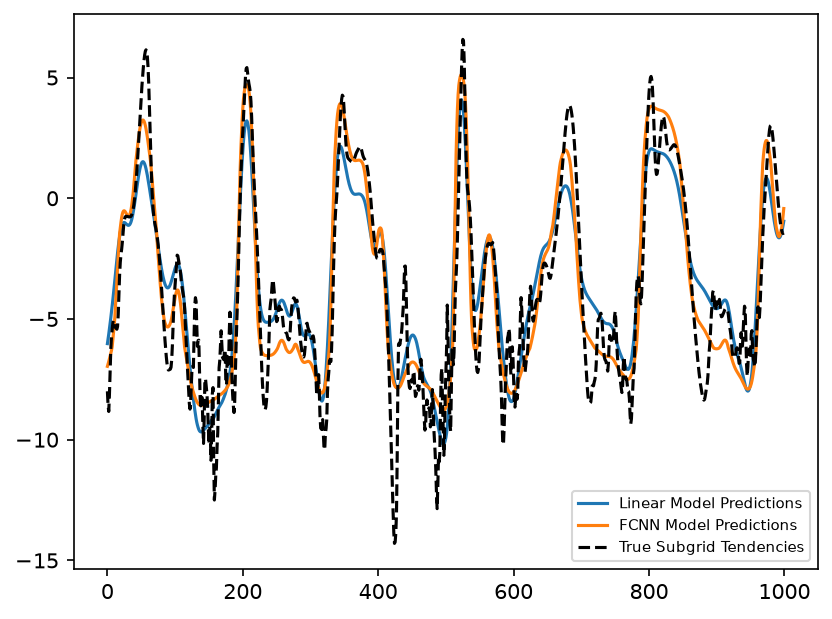

In [51]:
predictions_linear = linear_network(torch.unsqueeze(torch.from_numpy(np.reshape(X_true_test[:, 1], -1)), 1).to(device)).cpu().detach().numpy()
predictions_fcnn = fcnn_network(torch.unsqueeze(torch.from_numpy(np.reshape(X_true_test[:, 1], -1)), 1).to(device)).cpu().detach().numpy()

plt.figure(dpi=150)
plt.plot(predictions_linear[0:1000], label='Linear Model Predictions')
plt.plot(predictions_fcnn[0:1000], label='FCNN Model Predictions')
plt.plot(subgrid_tendencies_test[:1000, 1], label='True Subgrid Tendencies', color='k', linestyle='--')
plt.legend(fontsize=7);

Text(0, 0.5, 'Subgrid Tendencies - U')

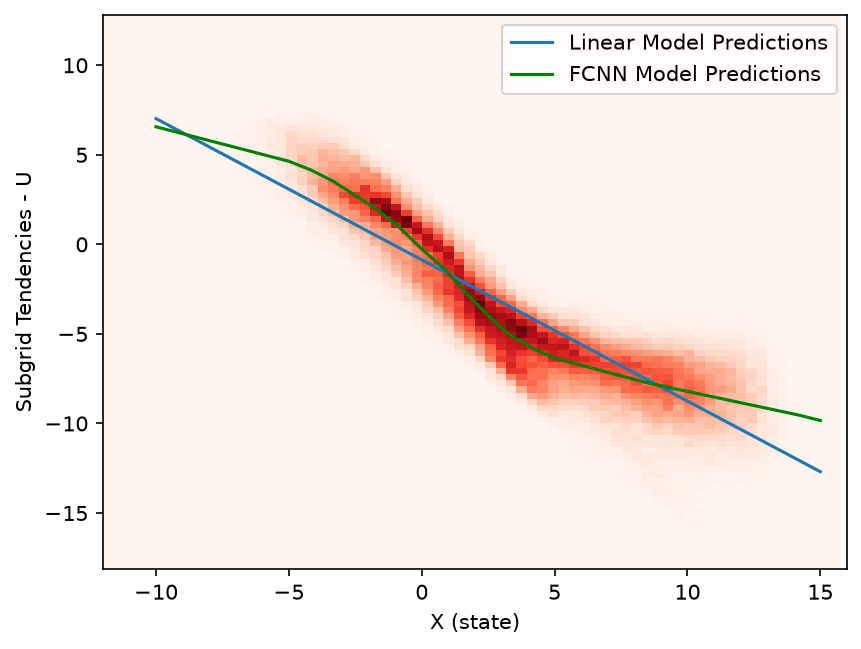

In [57]:
X_points = torch.from_numpy(np.linspace(-10, 15, 31).astype(np.float32)).to(device)
linear_pred = linear_network(torch.unsqueeze(X_points, 1)).cpu().detach().numpy()
fcnn_pred = fcnn_network(torch.unsqueeze(X_points, 1)).cpu().detach().numpy()

plt.figure(dpi=150)
plt.hist2d(np.reshape(X_true, -1), np.reshape(xy_true, -1), bins=91, cmap='Reds')

plt.plot(X_points.cpu().numpy(), linear_pred, "-", label='Linear Model Predictions')
plt.plot(X_points.cpu().numpy(), fcnn_pred, "-", label='FCNN Model Predictions', color='g')

plt.legend()
plt.xlim([-12, 16])
plt.xlabel('X (state)')
plt.ylabel('Subgrid Tendencies - U')

## The *non-local* models:

It is possible that the sub-tendencies depend on the state of the system at other locations, i.e. at neighbouring $k$ s.


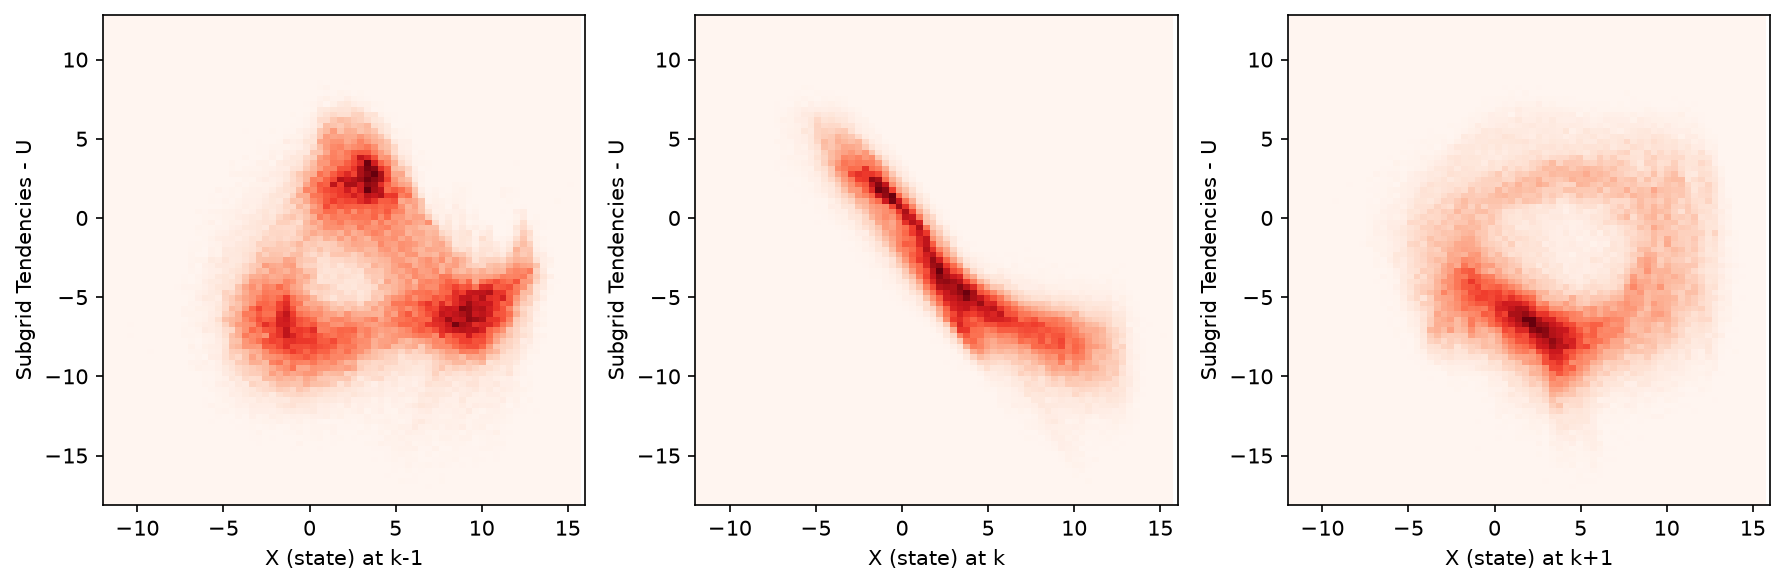

In [58]:
plt.figure(figsize=(12, 4), dpi=150)

plt.subplot(131)
plt.hist2d(
  np.reshape(np.roll(X_true, -1, axis=1), -1),
  np.reshape(xy_true, -1),
  bins=91,
  cmap='Reds'
)
plt.xlim([-12, 16])
plt.xlabel('X (state) at k-1')
plt.ylabel('Subgrid Tendencies - U')

plt.subplot(132)
plt.hist2d(
  np.reshape(X_true, -1),
  np.reshape(xy_true, -1),
  bins=91,
  cmap='Reds'
)
plt.xlim([-12, 16])
plt.xlabel('X (state) at k')
plt.ylabel('Subgrid Tendencies - U')

plt.subplot(133)
plt.hist2d(
  np.reshape(np.roll(X_true, 1, axis=1), -1),
  np.reshape(xy_true, -1),
  bins=91,
  cmap='Reds'
)
plt.xlim([-12, 16])
plt.xlabel('X (state) at k+1')
plt.ylabel('Subgrid Tendencies - U')

plt.tight_layout()

We shall build a non-local model, which uses all $X_k$ s to predict the sub-tendencies at a given $k$. 
To build this model, we need to modify two things:
* The datasets need to be slightly altered, such that each sample for the ML model will be comprised of all eight $K$ points.
* The architecture of the neural network needs to be modified, such that the input layer has 8 nodes, and the output layer has 8 nodes. The hidden layers can be set to any number of nodes, which is a hyperparameter.

In [59]:
nlocal_data_train = Data.TensorDataset(torch.from_numpy(X_true_train), torch.from_numpy(subgrid_tendencies_train))
nlocal_dataloader_train = Data.DataLoader(dataset=nlocal_data_train, batch_size=BATCH_SIZE, shuffle=True)

nlocal_data_test = Data.TensorDataset(torch.from_numpy(X_true_test), torch.from_numpy(subgrid_tendencies_test))
nlocal_dataloader_test = Data.DataLoader(dataset=nlocal_data_test, batch_size=BATCH_SIZE, shuffle=True)

In [60]:
class NonLocalFCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear1 = nn.Linear(8, 16) # 8 inputs and 16 outputs
        self.linear2 = nn.Linear(16, 16) # 16 inputs and 16 outputs
        self.linear3 = nn.Linear(16, 8) # 16 inputs and 8 outputs
        self.relu = nn.ReLU() # ReLU activation function  
    def forward(self, x):
        x = self.relu(self.linear1(x)) # apply linear1 and ReLU
        x = self.relu(self.linear2(x)) # apply linear2 and ReLU
        x = self.linear3(x) # apply linear3
        return x

In [61]:
nonlocal_fcnn_network = NonLocalFCNN()

In [62]:
optimizer_nonlocal_fcnn = optim.Adam(nonlocal_fcnn_network.parameters(), lr=learning_rate)

In [63]:
n_epochs = 120
train_loss_nonlocal_fcnn, test_loss_nonlocal_fcnn = fit_model(nonlocal_fcnn_network, loss_fn, optimizer_nonlocal_fcnn, nlocal_dataloader_train, nlocal_dataloader_test, n_epochs, device)

Epoch 1/120, Train Loss: 31.6209, Test Loss: 26.0851
Epoch 10/120, Train Loss: 7.2133, Test Loss: 7.2477
Epoch 20/120, Train Loss: 4.9473, Test Loss: 4.9818
Epoch 30/120, Train Loss: 4.7107, Test Loss: 4.1281
Epoch 40/120, Train Loss: 3.4247, Test Loss: 3.3958
Epoch 50/120, Train Loss: 3.0616, Test Loss: 3.1214
Epoch 60/120, Train Loss: 2.8305, Test Loss: 2.9394
Epoch 70/120, Train Loss: 2.8533, Test Loss: 2.9078
Epoch 80/120, Train Loss: 2.7769, Test Loss: 2.8164
Epoch 90/120, Train Loss: 2.5701, Test Loss: 2.6848
Epoch 100/120, Train Loss: 2.8038, Test Loss: 2.6708
Epoch 110/120, Train Loss: 2.6787, Test Loss: 2.6829
Epoch 120/120, Train Loss: 2.9004, Test Loss: 2.6745
Training completed in 43.18 seconds.


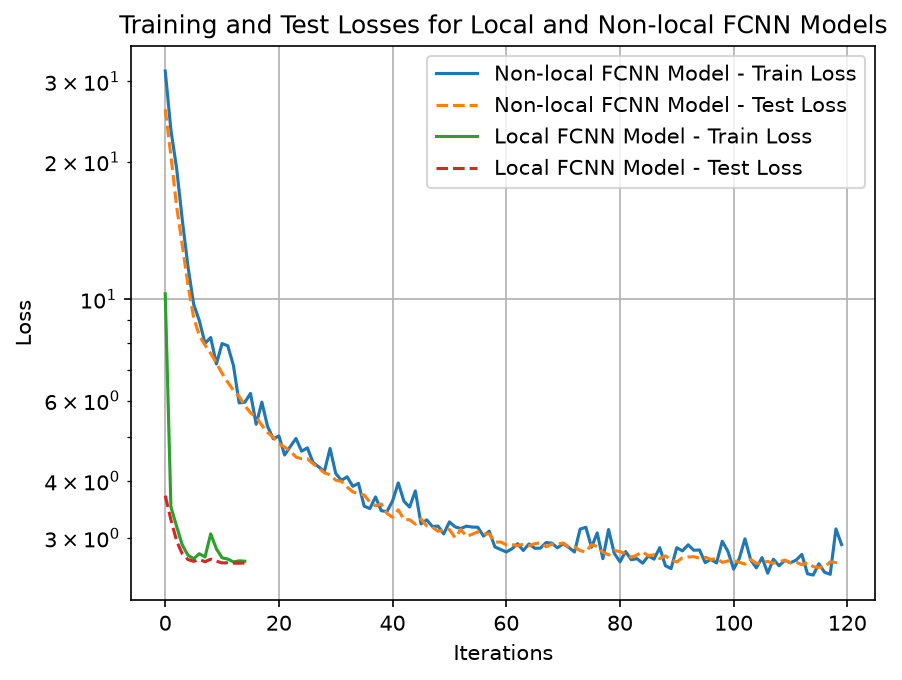

In [64]:
plt.figure(dpi=150)
plt.plot(train_loss_nonlocal_fcnn, label='Non-local FCNN Model - Train Loss')
plt.plot(test_loss_nonlocal_fcnn, linestyle='--', label='Non-local FCNN Model - Test Loss')

plt.plot(train_loss_fcnn, label='Local FCNN Model - Train Loss')
plt.plot(test_loss_fcnn, linestyle='--', label='Local FCNN Model - Test Loss')

plt.legend()
plt.xlabel('Iterations')
plt.ylabel('Loss')
plt.yscale('log')
plt.title('Training and Test Losses for Local and Non-local FCNN Models')
plt.grid()
plt.show();

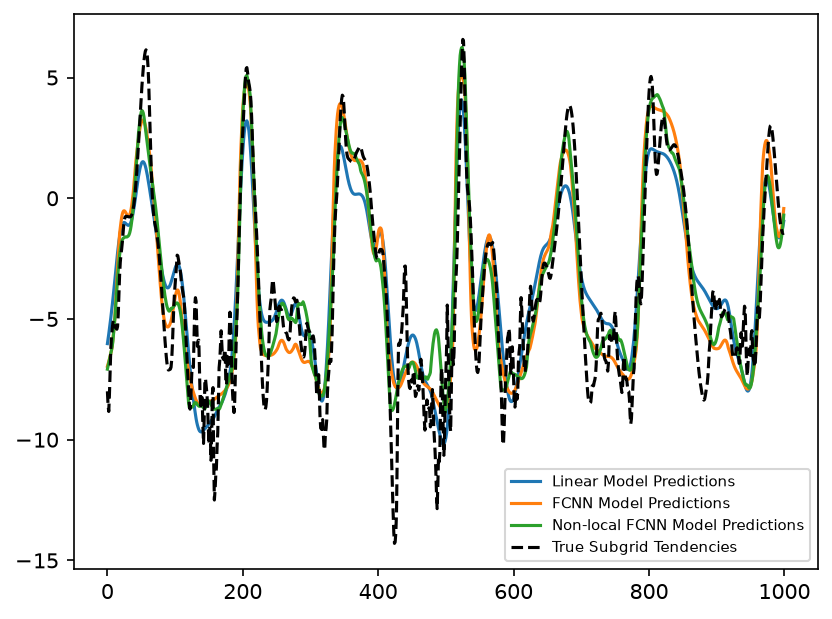

In [65]:
k_loc = 1
predictions_linear = linear_network(torch.unsqueeze(torch.from_numpy(np.reshape(X_true_test[:, k_loc], -1)), 1).to(device)).cpu().detach().numpy()
predictions_fcnn = fcnn_network(torch.unsqueeze(torch.from_numpy(np.reshape(X_true_test[:, k_loc], -1)), 1).to(device)).cpu().detach().numpy()
predictions_nonlocal_fcnn = nonlocal_fcnn_network(torch.from_numpy(X_true_test).to(device)).cpu().detach().numpy()[:, k_loc]

plt.figure(dpi=150)
plt.plot(predictions_linear[0:1000], label='Linear Model Predictions')
plt.plot(predictions_fcnn[0:1000], label='FCNN Model Predictions')
plt.plot(predictions_nonlocal_fcnn[0:1000], label='Non-local FCNN Model Predictions')
plt.plot(subgrid_tendencies_test[:1000, k_loc], label='True Subgrid Tendencies', color='k', linestyle='--')
plt.legend(fontsize=7);

In [66]:
save_path = os.path.join(parent_dir, "models")
if not os.path.exists(save_path):
    os.makedirs(save_path)
torch.save(linear_network.state_dict(), os.path.join(save_path, "linear_model.pth"))
torch.save(fcnn_network.state_dict(), os.path.join(save_path, "fcnn_model.pth"))
torch.save(nonlocal_fcnn_network.state_dict(), os.path.join(save_path, "nonlocal_fcnn_model.pth"))